Introduction to project

Over the past several years, cybersecurity attacks have increased significantly, posing serious risks to organizations and individuals worldwide. As cyber threats continue to evolve, it is important to investigate which network and user behavior characteristics are most strongly associated with malicious activity. By identifying these patterns, security professionals can better understand threats and develop more effective detection methods.

Research Question:

What characteristics are most associated with cybersecurity attacks, and can machine learning models accurately detect them?

In [171]:
import pandas as pd #load the data
import sqlite3      #inspect the data

In [172]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [173]:
import sqlite3

conn = sqlite3.connect("cybersecurity_intrusion_data.db") #conn is door to database

df.to_sql("logs",conn,if_exists="replace",index=False) #uploaded dataframe to database

9537

In [174]:
query = "SELECT COUNT(*) FROM logs WHERE attack_detected=1"

df = pd.read_sql(query, conn)
print(df["COUNT(*)"][0])

#There were 4264 attacks detected in this dataset

4264


Well lets look and find the answers to some major questions about this dataset.

In [175]:
query = """
SELECT login_attempts, AVG(attack_detected) * 100 AS attack_rate,
COUNT(*) AS count
FROM logs
GROUP BY login_attempts
ORDER BY login_attempts;
"""
df = pd.read_sql(query, conn)
print(df)

    login_attempts  attack_rate  count
0                1    35.599078    868
1                2    36.023478   1363
2                3    36.225597   1844
3                4    41.399891   1843
4                5    38.847584   1614
5                6    37.863071    964
6                7   100.000000    567
7                8   100.000000    268
8                9   100.000000    124
9               10   100.000000     47
10              11   100.000000     22
11              12   100.000000      8
12              13   100.000000      5


Woah this is pretty interesting, after 7 or more login attempts, the attack_rate jumps to 100%! lets graph this.

In [176]:
import matplotlib.pyplot as plt

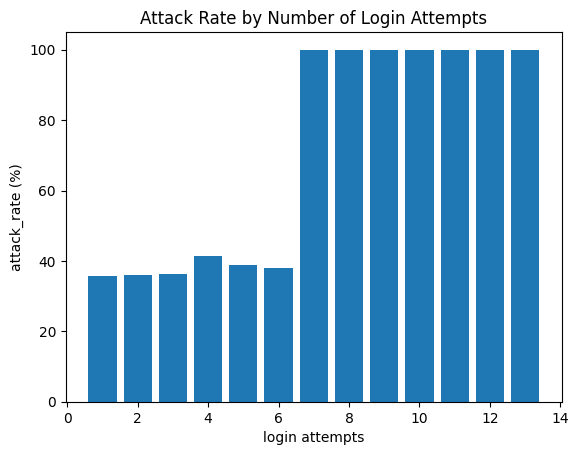

In [177]:
plt.bar(df["login_attempts"],df["attack_rate"])
plt.xlabel("login attempts")
plt.ylabel("attack_rate (%)")
plt.title("Attack Rate by Number of Login Attempts")
plt.show()

The number of login attempts appears to be associated with attack activity. Records with 1-6 login attempts exhibit attack rates between approximately 35% and 41%. However, records with 7 or more login attempts show a 100% attack rate. This suggests that unusually high numbers of login attempts are a strong indicator of malicious activity within this dataset.

In [178]:
#Which protocol experiences the most attacks?

query = """
SELECT protocol_type, COUNT(*) AS count
FROM logs
WHERE attack_detected=1

GROUP BY protocol_type
ORDER BY count DESC
LIMIT 1;
"""
df = pd.read_sql(query, conn)
print(df)

  protocol_type  count
0           TCP   2963


The TCP protocol experiences the most attacks in this dataset. Lets dig deeper and see if there are any correlations between the TCP protocol and cyber attacks.

In [179]:
query = """
SELECT attack_detected, protocol_type, COUNT(*) AS count
FROM logs

GROUP BY attack_detected, protocol_type
ORDER BY attack_detected, count DESC;
"""
df = pd.read_sql(query, conn)
print(df)

   attack_detected protocol_type  count
0                0           TCP   3661
1                0           UDP   1314
2                0          ICMP    298
3                1           TCP   2963
4                1           UDP   1092
5                1          ICMP    209


The protocol distribution among attack and non-attack records is nearly identical. Approximately 69% of records use TCP, 25% use UDP, and 5% use ICMP in both groups. This suggests that protocol type alone may not be a strong indicator of whether a record is malicious.

In [180]:
# lets find the attack rate by encryption type

query = """
SELECT encryption_used,
AVG(attack_detected) as attack_rate
FROM logs
GROUP BY encryption_used
ORDER BY attack_rate DESC;
"""
df = pd.read_sql(query, conn)
print(df)

  encryption_used  attack_rate
0            None     0.462869
1             DES     0.453403
2             AES     0.436677


Based on the analysis, records using no encryption (None) had the highest observed attack rate, suggesting a greater association with malicious activity compared to AES and DES within this dataset.

In [181]:
# Do attackers access systems at unusual times?

query = """
SELECT unusual_time_access, COUNT(*)
FROM LOGS
WHERE attack_detected = 1
GROUP BY unusual_time_access
"""
df = pd.read_sql(query, conn)
print(df)

   unusual_time_access  COUNT(*)
0                    0      3610
1                    1       654


From the results above, we can clearly see that around 4.83 times as much attacks happen during outside business hours.

In [182]:
query = """
SELECT CASE
WHEN ip_reputation_score < 0.2 THEN '<0.2'
WHEN ip_reputation_score < 0.4 THEN '0.2-0.4'
WHEN ip_reputation_score < 0.6 THEN '0.4-0.6'
WHEN ip_reputation_score < 0.8 THEN '0.6-0.8'
ELSE '0.8+'
END AS score_group,
AVG(attack_detected) * 100 AS attack_rate,
COUNT(*) AS count
FROM logs
GROUP BY score_group;
"""
df = pd.read_sql(query, conn)
print(df)

  score_group  attack_rate  count
0     0.2-0.4    40.894819   3822
1     0.4-0.6    39.613120   2378
2     0.6-0.8   100.000000    731
3        0.8+   100.000000     62
4        <0.2    37.971698   2544


It looks like in this dataset every record with an IP reputation score above 0.6 is labeled as an attack.

In [183]:
query = """
SELECT MAX(ip_reputation_score)
FROM logs
WHERE attack_detected = 0;
"""
df = pd.read_sql(query, conn)
print(df)

   MAX(ip_reputation_score)
0                  0.599703


IP reputation score appears to be strongly associated with attack activity. While attacks occurred across the entire range of IP reputation scores, no non-attack records were observed with scores above 0.60. Consequently, all records with IP reputation scores greater than 0.60 were classified as attacks, resulting in a 100% attack rate in those ranges.

In [184]:
query = """
SELECT CASE

WHEN network_packet_size < 500 THEN '<500'
WHEN network_packet_size < 1000 THEN '500-1000'
WHEN network_packet_size < 1500 THEN '1000-1500'
ELSE '1500+'
END AS size_group,

AVG(attack_detected) * 100 AS attack_rate,
COUNT(*) AS count
FROM logs
GROUP BY size_group;

"""
df = pd.read_sql(query, conn)
print(df)

  size_group  attack_rate  count
0  1000-1500    40.298507     67
1   500-1000    44.884910   4692
2       <500    44.600251   4778


Network packet size does not appear to be strongly associated with attacks. Attack rates remained relatively consistent across packet size ranges, varying only between approximately 40% and 45%.

**Summary of Findings**

The objective of this analysis was to identify characteristics that are most strongly associated with cyber attacks within the dataset. Several variables were examined, including login attempts, encryption methods, access timing, IP reputation scores, session duration, and network packet size.

**Key Findings**

The analysis identified several factors that appear to be associated with a higher likelihood of attack activity:

**Login Attempts:** Attack rates increased substantially with the number of login attempts. Records containing seven or more login attempts exhibited a 100% attack rate, suggesting that excessive login activity is a strong indicator of potential malicious behavior.

**Encryption Type:** Records utilizing no encryption (None) demonstrated the highest attack rate among the encryption categories examined. This finding suggests that unencrypted connections may be more susceptible to malicious activity than records using AES or DES encryption within this dataset.

**Access Time:** Attack activity was significantly more common during unusual access periods. Approximately 4.83 times more attacks occurred outside normal business hours than during regular business hours, indicating that access time may be an important indicator of suspicious behavior.

**IP Reputation Score:** IP reputation score showed a strong relationship with attack occurrence. While attacks were present across the entire range of reputation scores, no non-attack records were observed with scores above 0.60. As a result, all records with IP reputation scores greater than 0.60 were classified as attacks, producing a 100% attack rate within those ranges.

**Overall Conclusion**

Based on the exploratory data analysis, login attempts, IP reputation score, encryption type, and unusual access times appear to be the strongest indicators of cyber attack activity in this dataset. In contrast, variables such as session duration and network packet size showed relatively weak relationships with attack occurrence. These findings suggest that behavioral and security-related attributes may be more valuable predictors for a machine learning model designed to detect cyber attacks.

***Can a machine learning model detect which features are the strongest indicators of cyber attacks?***

In [185]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [186]:
df_encoded = pd.get_dummies(df, columns = ["protocol_type","encryption_used","browser_type"],dtype=int)
df_encoded = df_encoded.drop("session_id",axis=1)

y = df_encoded["attack_detected"]

df_encoded = df_encoded.drop("attack_detected",axis=1)
df_encoded.head()

x = df_encoded

In [187]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state =42)

In [188]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train, y_train) #learning patters

RandomForestClassifier(random_state=42)

In [189]:
# make predictions

y_pred = rf.predict(X_test)

print(y_pred)

[0 0 1 ... 0 0 0]


In [190]:
# lets get a classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1042
           1       0.99      0.77      0.87       866

    accuracy                           0.89      1908
   macro avg       0.91      0.88      0.89      1908
weighted avg       0.91      0.89      0.89      1908



The Random Forest model achieved an overall accuracy of 89%. For attack detection, the model achieved a precision of 99%, meaning that attack predictions were almost always correct. The model achieved a recall of 77%, meaning it successfully detected approximately 77% of all attacks while missing about 23% of them. This indicates that the model is highly reliable when flagging an attack but could be improved to identify a greater proportion of attacks.

Now lets look at feature importance, answering the question: What characteristics are most associated with cyber attacks?

In [191]:
importance = pd.DataFrame({"Feature": x.columns,"Importance": rf.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

                 Feature  Importance
4          failed_logins    0.281193
3    ip_reputation_score    0.228871
1         login_attempts    0.214643
2       session_duration    0.102663
0    network_packet_size    0.093562
15  browser_type_Unknown    0.023832
5    unusual_time_access    0.008781
10   encryption_used_DES    0.007967
9    encryption_used_AES    0.007415
13  browser_type_Firefox    0.005831
11   browser_type_Chrome    0.005158
7      protocol_type_TCP    0.004820
8      protocol_type_UDP    0.004768
12     browser_type_Edge    0.004574
14   browser_type_Safari    0.003169
6     protocol_type_ICMP    0.002753


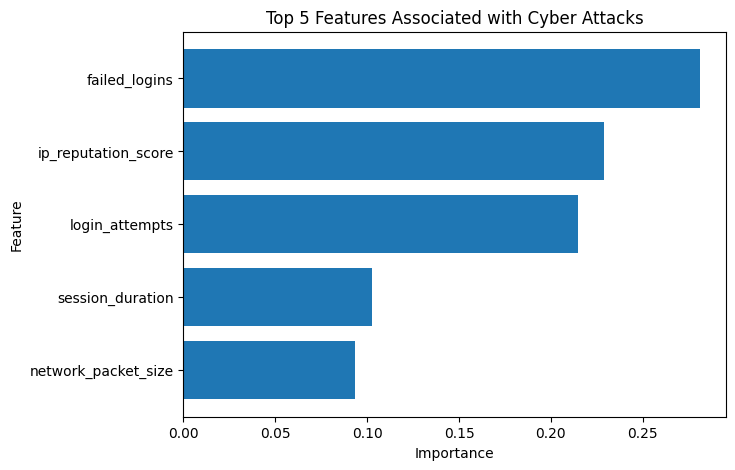

In [192]:
top_five = importance.head(5)

plt.figure(figsize=(7,5))

#creating the bar
plt.barh(top_five["Feature"], top_five["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Top 5 Features Associated with Cyber Attacks")
plt.gca().invert_yaxis()
plt.show()

The Random Forest model identified the top five features most strongly associated with cyber attacks. Failed logins had the highest importance score, followed by IP reputation score and login attempts. Session duration and network packet size also contributed to attack prediction, though to a lesser extent. These findings suggest that authentication-related activity and network behavior are key indicators of potential cyber attacks.